## BANK CUSTOMER & TRANSACTION ANALYSIS

### Objectives
- What is the total number of transactions?
- What is the total transaction amount?
- How are transactions distributed between Debit and Credit?
- Which transaction type has the higher average transaction amount?
- Which locations have the highest transaction activity?
- Which transaction channel is most frequently used by customers?
- Which age group has the highest transaction activity?
- Which customer occupations have the highest transaction activity?
- How does the average account balance differ between Debit and Credit transactions?
- How does transaction duration vary across different transaction channels?
- Which month had the highest number of transactions?
- Which locations had a total transaction amount higher than the overall average transaction amount?
- Which transactions had an amount greater than the average transaction amount?
- What is the transaction rank of each transaction within its transaction type based on transaction amount?
- What is the running total of transaction amounts over time?

In [1]:
# Importing Libraries:-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [2]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234",
    database="Bank_Transaction_Analysis"
)

print("Connected successfully!")

Connected successfully!


In [3]:
query = "SELECT * FROM bank_transactions"

df = pd.read_sql(query, conn)

C:\Users\hp\AppData\Local\Temp\ipykernel_21740\1332770988.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [4]:
df.shape

(2512, 17)

In [5]:
df.columns

Index(['Transaction_ID', 'Account_ID', 'Transaction_Amount',
       'Transaction_Date', 'Transaction_Type', 'Location', 'Device_ID',
       'IP_Address', 'Merchant_ID', 'Transaction_Channel', 'Customer_Age',
       'Customer_Occupation', 'Transaction_Duration', 'Login_Attempts',
       'Account_Balance', 'Previous_Transaction_Date', 'Row_ID'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Transaction_ID             2512 non-null   str           
 1   Account_ID                 2491 non-null   str           
 2   Transaction_Amount         2486 non-null   float64       
 3   Transaction_Date           2484 non-null   datetime64[us]
 4   Transaction_Type           2482 non-null   str           
 5   Location                   2483 non-null   str           
 6   Device_ID                  2482 non-null   str           
 7   IP_Address                 2492 non-null   str           
 8   Merchant_ID                2489 non-null   str           
 9   Transaction_Channel        2485 non-null   str           
 10  Customer_Age               2494 non-null   float64       
 11  Customer_Occupation        2489 non-null   str           
 12  Transaction_Durat

In [7]:
df.describe()

,Transaction_Amount,Transaction_Date,Customer_Age,Transaction_Duration,Login_Attempts,Account_Balance,Previous_Transaction_Date,Row_ID
count,2486.000000,2484,2494.000000,2486.000000,2491.000000,2485.000000,2488,2512.000000
mean,297.916621,2023-07-05 18:14:21.231884,44.631115,119.592116,1.122842,5117.740427,2024-11-04 08:08:53.175241,1257.775876
min,0.260000,2023-01-02 16:00:00,18.000000,10.000000,1.000000,101.250000,2024-11-04 08:06:00,1.000000
25%,81.390000,2023-04-03 16:08:30,27.000000,63.000000,1.000000,1504.990000,2024-11-04 08:07:00,628.750000
50%,211.360000,2023-07-07 18:00:30,45.000000,113.000000,1.000000,4735.610000,2024-11-04 08:09:00,1256.500000
75%,413.797500,2023-10-06 18:40:15,59.000000,161.000000,1.000000,7682.000000,2024-11-04 08:10:00,1884.250000
max,1919.110000,2024-01-01 18:21:00,80.000000,300.000000,5.000000,14977.990000,2024-11-04 08:12:00,2537.000000
std,292.648610,NaN,17.808567,70.015038,0.597320,3899.560910,NaN,727.396961


In [8]:
print("Total Null Values :",df.isnull().sum())

Total Null Values : Transaction_ID                0
Account_ID                   21
Transaction_Amount           26
Transaction_Date             28
Transaction_Type             30
Location                     29
Device_ID                    30
IP_Address                   20
Merchant_ID                  23
Transaction_Channel          27
Customer_Age                 18
Customer_Occupation          23
Transaction_Duration         26
Login_Attempts               21
Account_Balance              27
Previous_Transaction_Date    24
Row_ID                        0
dtype: int64


In [9]:
df.head(5)

,Transaction_ID,Account_ID,Transaction_Amount,Transaction_Date,Transaction_Type,Location,Device_ID,IP_Address,Merchant_ID,Transaction_Channel,Customer_Age,Customer_Occupation,Transaction_Duration,Login_Attempts,Account_Balance,Previous_Transaction_Date,Row_ID
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:00,1
1,TX000058,AC00456,292.56,2023-03-03 17:37:00,Credit,Dallas,D000311,198.73.211.114,M075,Branch,68.0,Retired,61.0,1.0,4638.37,2024-11-04 08:07:00,2
2,TX000059,AC00143,386.52,2023-06-09 16:18:00,Debit,Indianapolis,D000145,186.54.68.246,M064,Branch,48.0,Engineer,28.0,1.0,5630.61,2024-11-04 08:07:00,3
3,TX000060,AC00427,112.07,2023-10-02 16:35:00,Debit,Kansas City,D000089,198.166.198.233,M064,Branch,23.0,Student,51.0,1.0,930.30,2024-11-04 08:11:00,4
4,TX000061,AC00438,568.52,2023-10-06 18:44:00,Debit,Indianapolis,D000233,27.143.109.203,M094,ATM,46.0,Engineer,152.0,1.0,5499.91,NaT,5


In [10]:
# 1.What is the total number of transactions?
print("Total Number Of Transactions:",df.Transaction_ID.count())

Total Number Of Transactions: 2512


## Insight
- This dataset contains 2,512 transaction records, with 347 null values retained across the dataset.

In [11]:
# 2.What is the total transaction amount?
print("Total Transaction Amount:",df.Transaction_Amount.sum())

Total Transaction Amount: 740620.72


## Insight
- The total transaction amount recorded in the dataset is 740,620.72 across the recorded transactions.

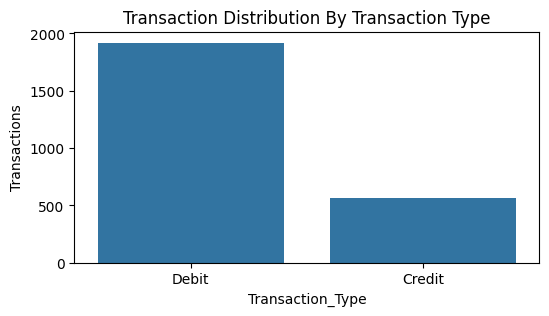

In [12]:
# 3.How are transactions distributed between Debit and Credit?
plt.figure(figsize=(6,3))
sns.countplot(x='Transaction_Type',data=df)
plt.title('Transaction Distribution By Transaction Type')
plt.xlabel('Transaction_Type')
plt.ylabel('Transactions')
plt.show()

## Insight
- This dataset contains 1,920 Debit transactions and 562 Credit transactions.
- This indicates that Debit transactions account for a larger proportion of transaction records than Credit transactions. 

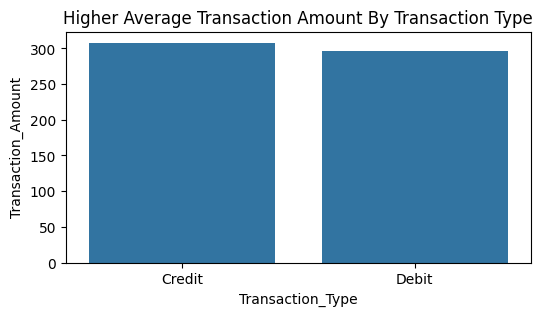

In [13]:
# 4.Which transaction type has the higher average transaction amount?
ata = df.groupby('Transaction_Type').agg({'Transaction_Amount':'mean'}).reset_index()
plt.figure(figsize=(6,3))
sns.barplot(x='Transaction_Type',y='Transaction_Amount',data=ata)
plt.title('Higher Average Transaction Amount By Transaction Type')
plt.xlabel('Transaction_Type')
plt.ylabel('Transaction_Amount')
plt.show()

## Insight
- The average transaction amount is 308.12 for Credit transactions and 295.64 for Debit transactions.
- This indicates that Credit transactions have a higher average transaction amount than Debit transactions.

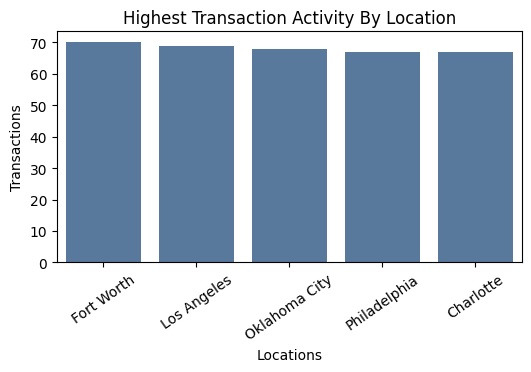

In [14]:
# 5.Which locations have the highest transaction activity?
tabl = df.groupby('Location').agg({'Transaction_ID':'count'
                           }).sort_values(by='Transaction_ID',ascending=False).reset_index().head()
plt.figure(figsize=(6,3))
sns.barplot(x='Location',y='Transaction_ID',data=tabl,color='#4C78A8')
plt.title('Highest Transaction Activity By Location')
plt.xlabel('Locations')
plt.ylabel('Transactions')
plt.xticks(rotation=35)
plt.show()

## Insight
- Fort Worth recorded 70 transactions in this dataset.
- This indicates that Fort Worth had the highest transaction activity among all locations.

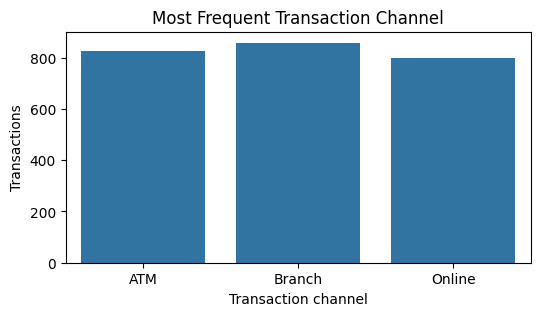

In [15]:
# 6. Which transaction channel is most frequently used by customers?
plt.figure(figsize=(6,3))
sns.countplot(x='Transaction_Channel',data=df)
plt.title('Most Frequent Transaction Channel')
plt.xlabel('Transaction channel')
plt.ylabel('Transactions')
plt.show()

## Insight
- This dataset contains 826 ATM transactions, 859 Branch transactions, and 800 Online transactions.
- This indicates that the three channels have a relatively similar number of transactions, with Branch having slightly more transactions than ATM and Online.
- Therefore, Branch is the most frequently used transaction channel by customers.

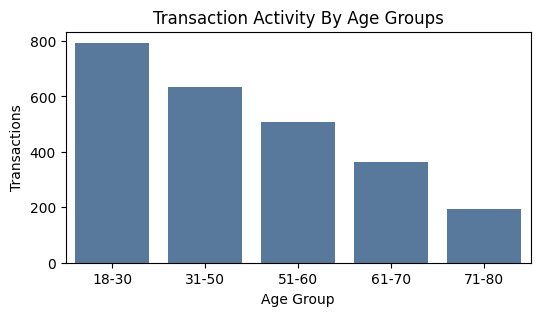

In [16]:
#7. Which age group has the highest transaction activity?
df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=[17,30,50,60,70,80],
    labels=['18-30','31-50','51-60','61-70','71-80']
)
plt.figure(figsize=(6,3))
sns.countplot(x='Age_Group',data=df,color='#4E79A7')
plt.title('Transaction Activity By Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Transactions')
plt.show()

## Insight
- The 18–30 age group has the highest transaction activity among all age groups in this dataset

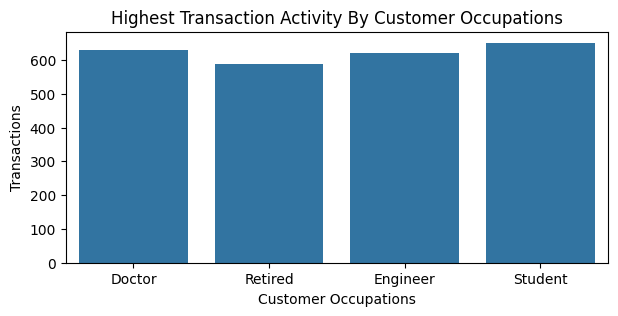

In [17]:
#8. Which customer occupations have the highest transaction activity?
plt.figure(figsize=(7,3))
sns.countplot(x='Customer_Occupation',data=df)
plt.title('Highest Transaction Activity By Customer Occupations')
plt.xlabel('Customer Occupations')
plt.ylabel('Transactions')
plt.show()

## Insight
- This dataset contains 629 transactions by Doctors, 589 by Retired customers, 620 by Engineers, and 651 by Students.
- This indicates that Doctors, Engineers, and Students have relatively similar transaction activity, while Retired customers have slightly fewer transactions.
- Therefore, Students have the highest transaction activity among these customer occupations.

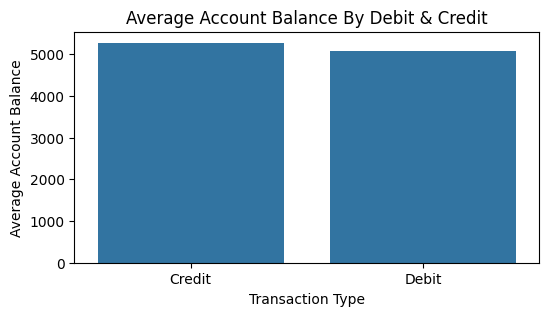

In [18]:
#9. How does the average account balance differ between Debit and Credit transactions?
acb = df.groupby('Transaction_Type').agg({'Account_Balance':'mean'}).reset_index().head()
plt.figure(figsize=(6,3))
sns.barplot(x='Transaction_Type',y='Account_Balance',data=acb)
plt.title('Average Account Balance By Debit & Credit')
plt.xlabel('Transaction Type')
plt.ylabel('Average Account Balance')
plt.show()

## Insight
- The average account balance is 5,077.86 for Debit transactions and 5,273.93 for Credit transactions.
- Credit transactions have a higher average account balance than Debit transactions.

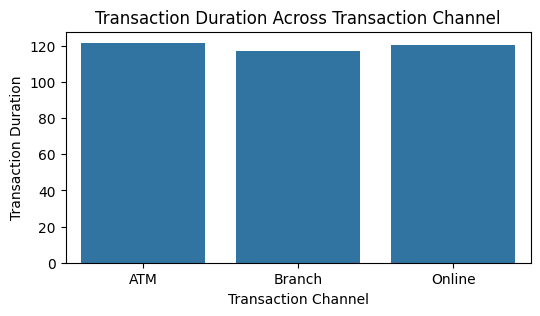

In [19]:
#10. How does transaction duration vary across different transaction channels?
td = df.groupby('Transaction_Channel').agg({'Transaction_Duration':'mean'}).reset_index()
plt.figure(figsize=(6,3))
sns.barplot(x='Transaction_Channel',y='Transaction_Duration',data=td)
plt.title('Transaction Duration Across Transaction Channel')
plt.xlabel('Transaction Channel')
plt.ylabel('Transaction Duration')
plt.show()

## Insight
- The average transaction duration is 121.70 seconds for ATM, 117.24 seconds for Branch, and 120.22 seconds for Online transactions.
- This indicates that the average transaction duration is relatively similar across all three channels, with Branch transactions having a slightly shorter duration.

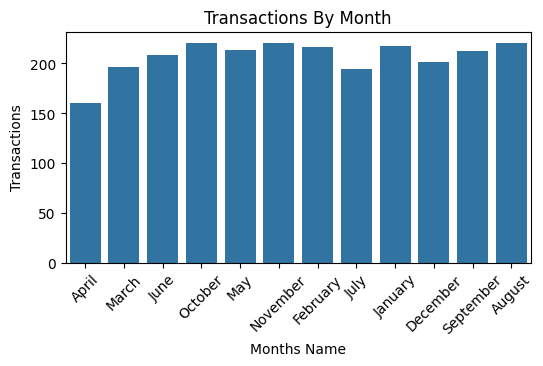

In [20]:
#11. Which month had the highest number of transactions?
df['Months_Name'] = df['Transaction_Date'].dt.month_name()
plt.figure(figsize=(6,3))
sns.countplot(x='Months_Name',data=df)
plt.title('Transactions By Month')
plt.xlabel('Months Name')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.show()

## Insight
- The number of transactions is relatively similar across most months, while April recorded slightly fewer transactions. August, October, and November each recorded 221 transactions.
- This indicates that August, October, and November had the highest number of transactions.

In [21]:
#12. Which locations had an average transaction amount higher than the overall average transaction amount?
atmbl = df.groupby('Location').agg({'Transaction_Amount':'mean'}).reset_index()
Average_Transaction_Amount = df.Transaction_Amount.mean()

fl = atmbl[atmbl['Transaction_Amount'] > Average_Transaction_Amount].sort_values(
    by='Transaction_Amount',ascending=False).reset_index().head()

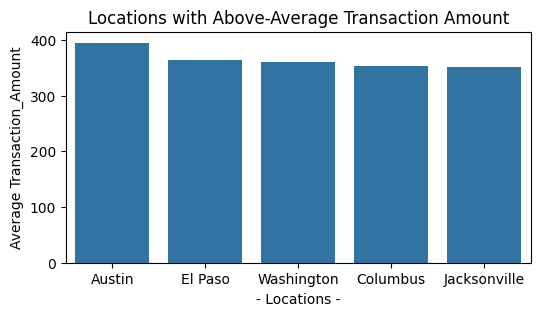

In [22]:
plt.figure(figsize=(6,3))
sns.barplot(x='Location',y='Transaction_Amount',data=fl)
plt.title('Locations with Above-Average Transaction Amount')
plt.xlabel('- Locations -')
plt.ylabel('Average Transaction_Amount')
plt.show()

## Insight
- This dataset contains several locations with an average transaction amount higher than the overall average, such as Austin (394.79), El Paso (364.57), and Washington (360.32).
- This indicates that Austin recorded the highest average transaction amount among these locations, but only slightly higher than the other locations mentioned.

In [23]:
#13. Which transactions had an amount greater than the average transaction amount?
df[df.Transaction_Amount > df.Transaction_Amount.mean()].sort_values(
    by = 'Transaction_Amount',ascending=False).reset_index().head()

,index,Transaction_ID,Account_ID,Transaction_Amount,Transaction_Date,Transaction_Type,Location,Device_ID,IP_Address,Merchant_ID,Transaction_Channel,Customer_Age,Customer_Occupation,Transaction_Duration,Login_Attempts,Account_Balance,Previous_Transaction_Date,Row_ID,Age_Group,Months_Name
0,491,TX000654,AC00423,1919.11,2023-06-27 17:48:00,Debit,Portland,D000191,207.157.126.125,M033,ATM,30.0,Doctor,161.0,1.0,11090.24,2024-11-04 08:10:00,492,18-30,June
1,1169,TX001439,AC00179,1831.02,2023-09-15 17:31:00,Credit,Columbus,D000246,141.121.30.32,M012,Online,62.0,Doctor,83.0,1.0,11498.01,2024-11-04 08:10:00,1170,61-70,September
2,336,TX000341,AC00107,1830.00,2023-03-01 16:31:00,Debit,San Antonio,D000436,62.27.235.199,M082,Online,55.0,Engineer,238.0,1.0,2235.70,2024-11-04 08:11:00,337,51-60,March
3,1539,TX001635,AC00358,1762.28,2023-10-06 16:05:00,Debit,Memphis,D000008,26.105.49.129,M066,ATM,24.0,Student,150.0,1.0,1380.34,2024-11-04 08:10:00,1540,18-30,October
4,2342,TX002415,AC00028,1664.33,2023-09-25 17:11:00,Debit,San Antonio,D000072,116.106.207.139,M064,Branch,18.0,Student,65.0,1.0,1588.31,2024-11-04 08:07:00,2345,18-30,September


In [24]:
#14. What is the transaction rank of each transaction within its transaction type based on transaction amount?
rank_df = df.dropna(subset=['Transaction_Type','Transaction_Amount'])

In [25]:
rank_df['Transaction_Rank'] = rank_df.groupby('Transaction_Type'
                                             )['Transaction_Amount'].rank(ascending=False)

In [26]:
rank_df[['Transaction_ID','Transaction_Type','Transaction_Amount',
         'Transaction_Rank']].sort_values(by = 'Transaction_Rank',ascending=True)

,Transaction_ID,Transaction_Type,Transaction_Amount,Transaction_Rank
491,TX000654,Debit,1919.11,1.0
1169,TX001439,Credit,1831.02,1.0
336,TX000341,Debit,1830.00,2.0
1092,TX001282,Credit,1397.59,2.0
1539,TX001635,Debit,1762.28,3.0
...,...,...,...,...
891,TX000930,Debit,0.86,1897.0
1975,TX001880,Debit,0.84,1898.0
2061,TX002260,Debit,0.45,1899.0
2050,TX002254,Debit,0.32,1900.0


In [27]:
#15. What is the running total of transaction amounts over time?
new_df = df.dropna(subset=['Transaction_Date'])

In [28]:
new_df = new_df.sort_values(by=['Transaction_Date','Transaction_ID'],
                            ascending=True)

In [29]:
new_df['Running_Total'] = new_df['Transaction_Amount'].cumsum()

In [30]:
new_df[['Transaction_ID','Transaction_Date','Transaction_Amount','Running_Total'
       ]].head(6)

,Transaction_ID,Transaction_Date,Transaction_Amount,Running_Total
1591,TX001063,2023-01-02 16:00:00,68.10,68.10
1237,TX001369,2023-01-02 16:01:00,487.16,555.26
1513,TX001623,2023-01-02 16:01:00,154.21,709.47
834,TX000983,2023-01-02 16:06:00,453.49,1162.96
753,TX000877,2023-01-02 16:07:00,204.06,1367.02
454,TX000639,2023-01-02 16:22:00,655.15,2022.17


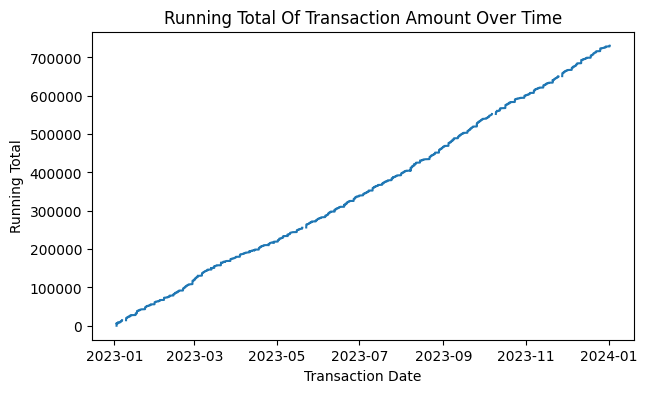

In [31]:
plt.figure(figsize=(7,4))
plt.plot(new_df['Transaction_Date'] , new_df['Running_Total'])
plt.title('Running Total Of Transaction Amount Over Time')
plt.xlabel('Transaction Date')
plt.ylabel('Running Total')
plt.show()

## Insight
- The running total of the transaction amount continuously increases over time as transaction amounts are accumulated.

# Final Conclusion
- This dataset contains 2,512 transaction records, with 347 NULL values retained across the dataset.
- The total transaction amount recorded in the dataset is 740,620.72 across the recorded transactions.
- This dataset contains 1,920 Debit transactions and 562 Credit transactions.
- The average transaction amount is 308.12 for Credit transactions and 295.64 for Debit transactions.
- This dataset contains 826 ATM transactions, 859 Branch transactions, and 800 Online transactions.
- The 18–30 age group has the highest transaction activity among all age groups in this dataset.
- This dataset contains 629 transactions by Doctors, 589 by Retired customers, 620 by Engineers, and 651 by Students.
- The average account balance is 5,077.86 for Debit transactions and 5,273.93 for Credit transactions.
- The average transaction duration is 121.70 seconds for ATM, 117.24 seconds for Branch, and 120.22 seconds for Online transactions.

# Overall Insight
- The analysis provides an overall view of transaction patterns across different transaction types, channels, customer age groups, occupations, locations, and transaction durations. The results show that Debit transactions are more frequent, while Credit transactions have a slightly higher average transaction amount and account balance. Transaction activity is relatively distributed across the three channels, with Branch being the most frequently used. The analysis also highlights differences in transaction activity across age groups, occupations, and locations, providing a broader understanding of customer transaction behavior in the dataset.